# Dự đoán doanh thu sản phẩm - Quy trình Machine Learning từng bước

Notebook này triển khai đầy đủ yêu cầu của bài Practice 2: Predicting Product Sales theo từng bước để dễ theo dõi.

Quy trình thực hiện:

| Bước | Nội dung |
| --- | --- |
| Bước 0 | Xác định bài toán |
| Bước 1 | Đọc dữ liệu |
| Bước 2 | Làm sạch và kiểm tra dữ liệu |
| Bước 3 | EDA phân phối biến mục tiêu |
| Bước 4 | EDA theo sản phẩm, địa lý, thời gian và bộ biểu đồ bổ sung |
| Bước 5 | Tạo đặc trưng |
| Bước 6 | Chọn tập đặc trưng, tiền xử lý và ghi chú thuật toán |
| Bước 7 | Huấn luyện và đánh giá mô hình |
| Bước 8 | Diễn giải, lựa chọn mô hình và biểu đồ chẩn đoán |
| Bước 9 | Lưu báo cáo và artifact |
| Bước 10 | Demo dự đoán |
| Bước 11 | Kết luận cuối cùng |

Biến mục tiêu: `Revenue`.

Lưu ý về rò rỉ dữ liệu: `Revenue = Quantity * Unit_Price`, nên notebook huấn luyện hai phiên bản:
- Model A: có dùng `Quantity`, dùng để minh họa rò rỉ dữ liệu.
- Model B: không dùng `Quantity`, dùng làm mô hình chính thực tế hơn.

## Bước 0. Xác định bài toán

Mục tiêu của bài toán là dự đoán doanh thu sản phẩm/đơn hàng để hỗ trợ quản lý tồn kho và xây dựng chiến lược marketing.

- Loại bài toán: hồi quy.
- Biến mục tiêu: `Revenue`.
- Chỉ số đánh giá chính: RMSE và MAE.
- Chỉ số đánh giá phụ: R2.
- Nguồn dữ liệu: `data/product_sales_dataset_final.csv`.

In [31]:
%matplotlib inline
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    display
except NameError:
    display = print

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "product_sales_dataset_final.csv"
REPORT_DIR = PROJECT_ROOT / "reports"
PLOT_DIR = REPORT_DIR / "plots"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Reusable project modules extracted from this notebook.
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import lab02.process as sales_process
import lab02.eda as sales_era
from lab02.model import (
    RidgeRegressionScratch,
    LinearRegressionScratch,
    LinearSVRRegressorScratch,
    MeanBaselineRegressorScratch,
    default_sklearn_linear_checker,
    default_sklearn_ridge_checker,
    default_sklearn_linear_svr_checker,
)

TARGET = "Revenue"
DATE_COLUMN = "Order_Date"
DATE_FORMAT = "%m-%d-%y"
RANDOM_STATE = 42
TEST_START_DATE = pd.Timestamp("2024-10-01")

DATA_PATH

PosixPath('/Users/quangmanh/Project/lab02/data/product_sales_dataset_final.csv')

## Bước 1. Đọc dữ liệu

In [32]:
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (200000, 14)


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


## Bước 2. Làm sạch và kiểm tra dữ liệu

Các bước thực hiện theo yêu cầu bài lab:
- Chuẩn hóa tên cột.
- Chuyển đổi cột ngày sang kiểu `datetime`.
- Kiểm tra giá trị thiếu.
- Kiểm tra dòng bị trùng lặp.
- Kiểm tra công thức `Revenue = Quantity * Unit_Price`.
- Ghi rõ những cột không dùng làm đặc trưng để tránh rò rỉ dữ liệu hoặc gây nhiễu.

In [33]:
df, checks = sales_process.load_clean_validate(DATA_PATH)
data_checks = checks.to_dict()

# Keep df_raw available from Step 1, but use the cleaned/validated df for all next steps.
assert df.shape == df_raw.shape

data_checks


{'rows': 200000,
 'columns': 14,
 'stripped_columns': [' Unit_Price ', ' Revenue ', ' Profit '],
 'missing_total': 0,
 'duplicate_rows': 0,
 'date_parse_failures': 0,
 'date_min': '2023-01-01',
 'date_max': '2024-12-31',
 'revenue_formula_mismatch_rows': 0,
 'revenue_formula_max_abs_diff': 0.0}

In [34]:
print("Data types:")
display(df.dtypes)

print("Missing values by column:")
display(pd.DataFrame({"missing": df.isna().sum(), "pct": df.isna().mean() * 100}))

print("Numeric summary:")
display(df[["Quantity", "Unit_Price", "Revenue", "Profit"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

print("Cardinality:")
display(df.nunique().sort_values(ascending=False))

Data types:


Order_ID                  int64
Order_Date       datetime64[us]
Customer_Name               str
City                        str
State                       str
Region                      str
Country                     str
Category                    str
Sub_Category                str
Product_Name                str
Quantity                  int64
Unit_Price              float64
Revenue                 float64
Profit                  float64
dtype: object

Missing values by column:


,missing,pct
Order_ID,0,0.0
Order_Date,0,0.0
Customer_Name,0,0.0
City,0,0.0
State,0,0.0
Region,0,0.0
Country,0,0.0
Category,0,0.0
Sub_Category,0,0.0
Product_Name,0,0.0


Numeric summary:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Quantity,200000.0,1.854000,1.100536,1.00,1.0000,1.00,1.0000,1.000,2.0000,4.0000,5.0000,11.00
Unit_Price,200000.0,382.855615,276.870235,17.03,33.7999,64.35,162.7600,303.545,562.2525,917.5600,1135.1613,1432.00
Revenue,200000.0,712.038725,742.471556,17.03,45.9600,85.14,229.1875,464.880,881.3025,2238.0045,3607.0494,9014.25
Profit,200000.0,157.743041,155.689581,3.92,11.7900,22.36,59.2100,109.530,199.4025,459.5505,766.3413,2763.72


Cardinality:


Order_ID         200000
Customer_Name    120230
Revenue          106202
Unit_Price        80524
Profit            46935
Order_Date          731
City                108
Product_Name         49
State                47
Sub_Category         19
Quantity             11
Region                4
Category              4
Country               1
dtype: int64

## Bước 3. EDA - Phân phối biến mục tiêu

In [35]:
target_summary = {
    "mean": df[TARGET].mean(),
    "median": df[TARGET].median(),
    "std": df[TARGET].std(),
    "min": df[TARGET].min(),
    "max": df[TARGET].max(),
    "skew": df[TARGET].skew(),
}
display(pd.Series(target_summary).round(4))
display(df[TARGET].quantile([.01, .05, .25, .5, .75, .95, .99]).round(2))

mean       712.0387
median     464.8800
std        742.4716
min         17.0300
max       9014.2500
skew         2.5357
dtype: float64

0.01      45.96
0.05      85.14
0.25     229.19
0.50     464.88
0.75     881.30
0.95    2238.00
0.99    3607.05
Name: Revenue, dtype: float64

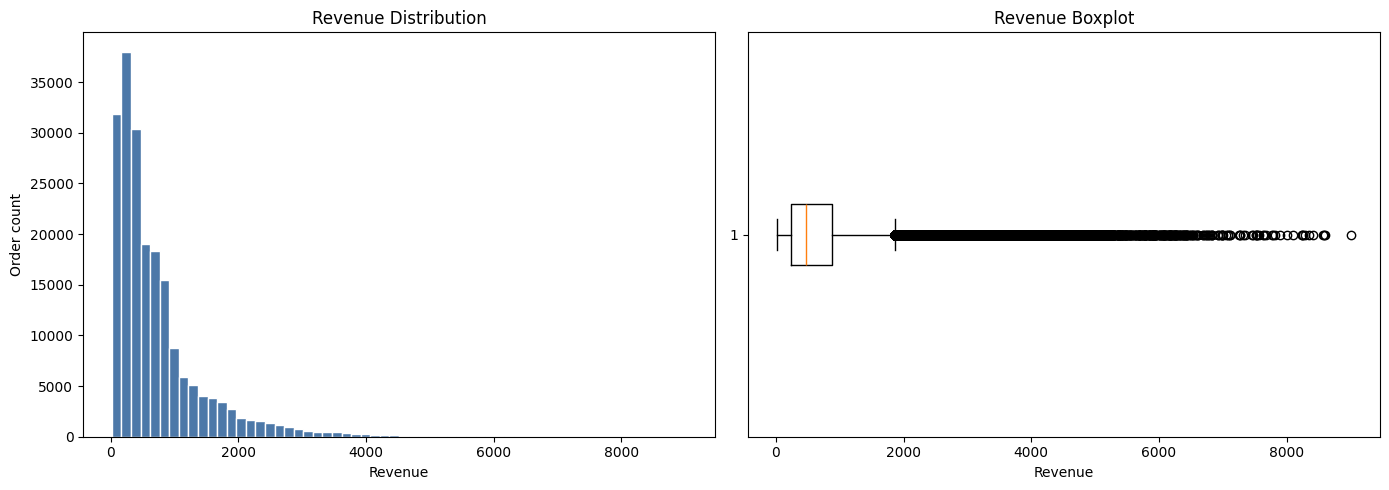

In [36]:
sales_era.plot_target_distribution(df, PLOT_DIR)

Nhận xét EDA cho biến mục tiêu:
- `Revenue` bị lệch phải, nên cần báo cáo cả MAE và RMSE.
- RMSE sẽ phạt nặng hơn các lỗi lớn ở những đơn hàng có doanh thu cao.
- Nếu muốn cải thiện thêm, có thể thử biến đổi `log1p(Revenue)`, nhưng notebook này giữ target ở thang đo gốc để các chỉ số dễ diễn giải.

## Bước 4. EDA - Sản phẩm, địa lý và thời gian

In [37]:
top_category = sales_era.group_sales(df, "Category")
top_sub_category = sales_era.group_sales(df, "Sub_Category")
top_product = sales_era.group_sales(df, "Product_Name")
top_region = sales_era.group_sales(df, "Region")
top_state = sales_era.group_sales(df, "State")
top_city = sales_era.group_sales(df, "City")

display(top_category)
display(top_sub_category)
display(top_product)
display(top_region)
display(top_state)
display(top_city)


,orders,quantity,revenue,avg_revenue,median_revenue
Category,,,,,
Electronics,51230,97115,57485698.06,1122.11,837.06
Home & Furniture,50564,90403,47674426.96,942.85,709.31
Clothing & Apparel,62298,115523,27134365.30,435.56,331.27
Accessories,35908,67759,10113254.61,281.64,213.30


,orders,quantity,revenue,avg_revenue,median_revenue
Sub_Category,,,,,
Bedding,10171,18575,13042783.30,1282.35,975.00
Laptops,8656,17630,12358319.81,1427.72,1037.54
Smartphones,8442,16985,10904335.31,1291.68,951.83
Furniture,10096,19002,9697778.92,960.56,722.46
Wearables,8563,16755,9216507.48,1076.32,810.12
Kitchenware,10091,19541,9117341.17,903.51,676.86
Home Appliances,8360,16080,8638544.88,1033.32,789.34
Tablets,8557,15187,8373830.76,978.59,760.46
Home Decor,10165,17024,8070216.82,793.92,625.06


,orders,quantity,revenue,avg_revenue,median_revenue
Product_Name,,,,,
Tempur-Pedic Mattress,5523,10333,9061755.86,1640.73,1221.98
Instant Pot,8657,18200,8903475.26,1028.47,768.11
MacBook Air,3926,8763,7362516.81,1875.32,1464.60
Apple Watch,5931,12368,6834472.35,1152.33,860.82
Apple iPhone 14,3636,7642,5740819.18,1578.88,1167.65
iPad Pro,5421,10075,5574458.89,1028.31,781.94
KitchenAid Mixer,5376,9831,4989740.69,928.15,703.52
Storage Rack,5707,9394,4463941.27,782.19,614.98
Brooklinen Sheets,4648,8242,3981027.44,856.50,660.93


,orders,quantity,revenue,avg_revenue,median_revenue
Region,,,,,
East,57034,105965,44980048.22,788.65,547.19
West,55428,102931,36242841.73,653.87,416.57
Centre,49603,91464,36081894.34,727.41,482.19
South,37935,70440,25102960.64,661.74,428.53


,orders,quantity,revenue,avg_revenue,median_revenue
State,,,,,
California,10272,19061,6766728.65,658.75,413.42
Arizona,10262,19032,6668187.20,649.79,411.23
New Jersey,5780,10712,4552067.75,787.55,548.01
Vermont,5677,10582,4550459.19,801.56,552.64
New York,5766,10730,4541307.27,787.60,551.28
Connecticut,5726,10666,4515748.44,788.64,545.68
Delaware,5673,10565,4515199.69,795.91,554.96
Pennsylvania,5765,10756,4495637.28,779.82,552.50
New Hampshire,5682,10532,4489012.87,790.04,539.04


,orders,quantity,revenue,avg_revenue,median_revenue
City,,,,,
Burlington,2920,5487,2367578.63,810.81,564.22
Manchester,2912,5349,2316261.28,795.42,548.09
Rochester,2905,5416,2312165.68,795.93,556.44
Wilmington,2874,5406,2311588.97,804.31,560.91
Providence,2901,5355,2298465.51,792.30,537.81
Jersey City,2905,5343,2290243.36,788.38,556.06
Boston,2878,5353,2274264.86,790.22,531.81
Philadelphia,2833,5279,2262453.14,798.61,571.82
Newark,2875,5369,2261824.39,786.72,541.26


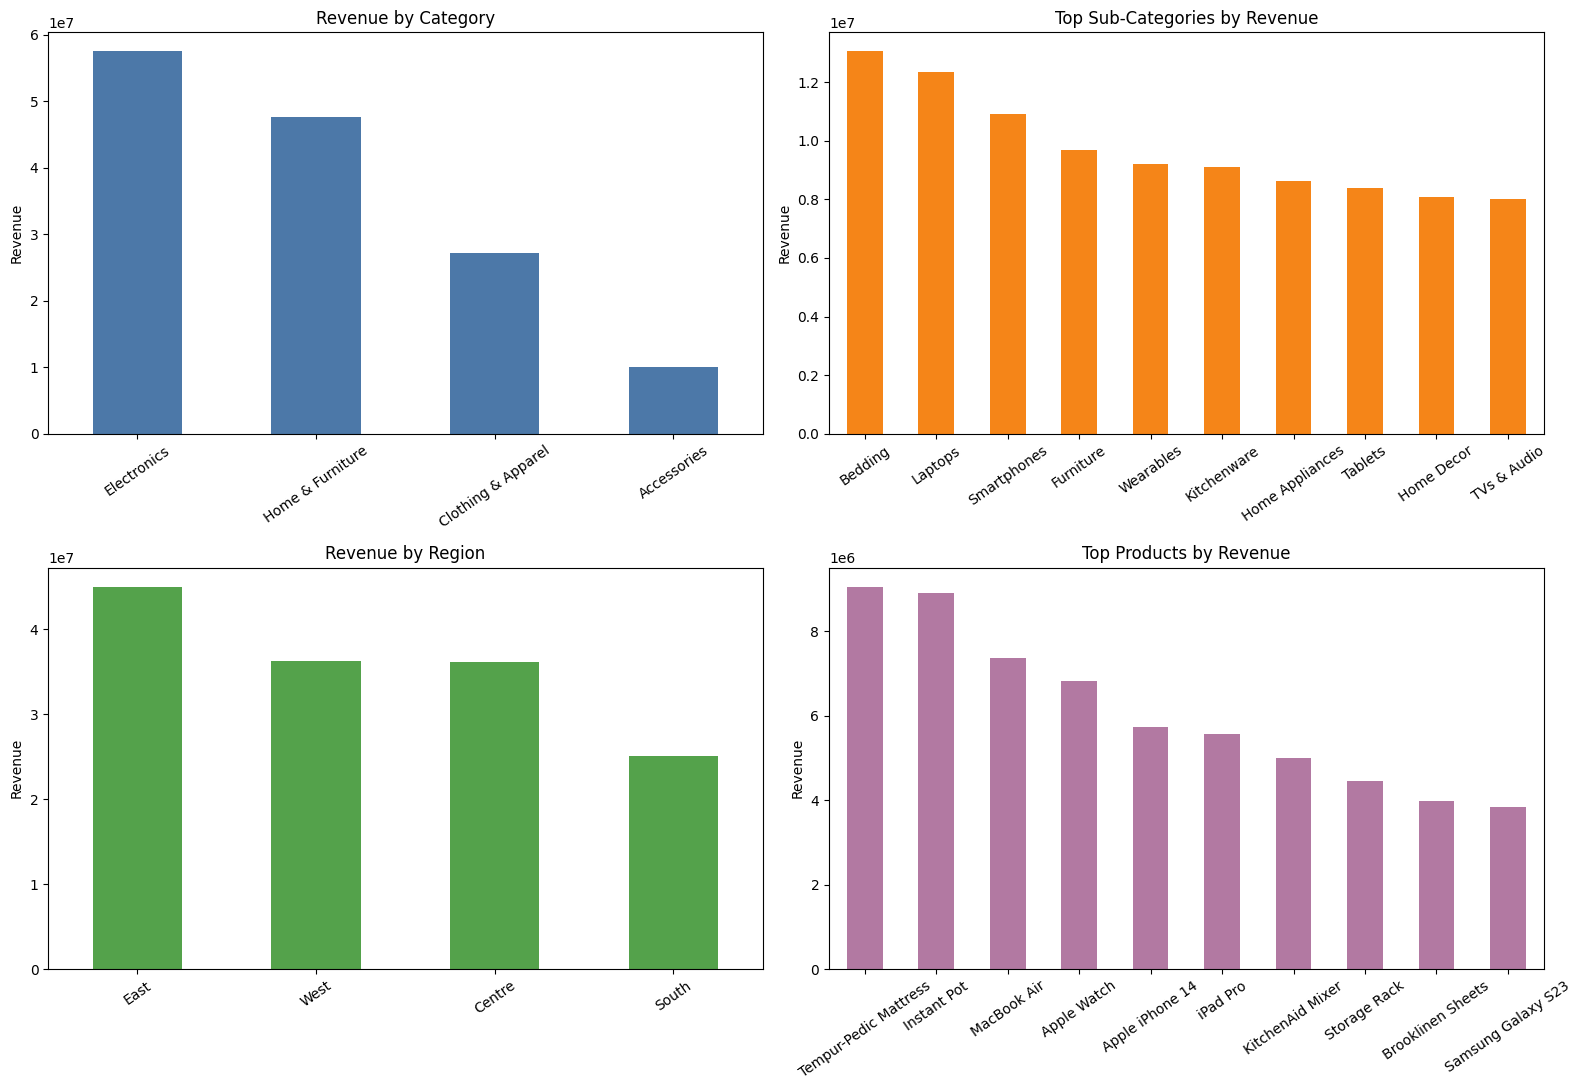

In [38]:
sales_era.plot_product_geography_eda(df, PLOT_DIR)

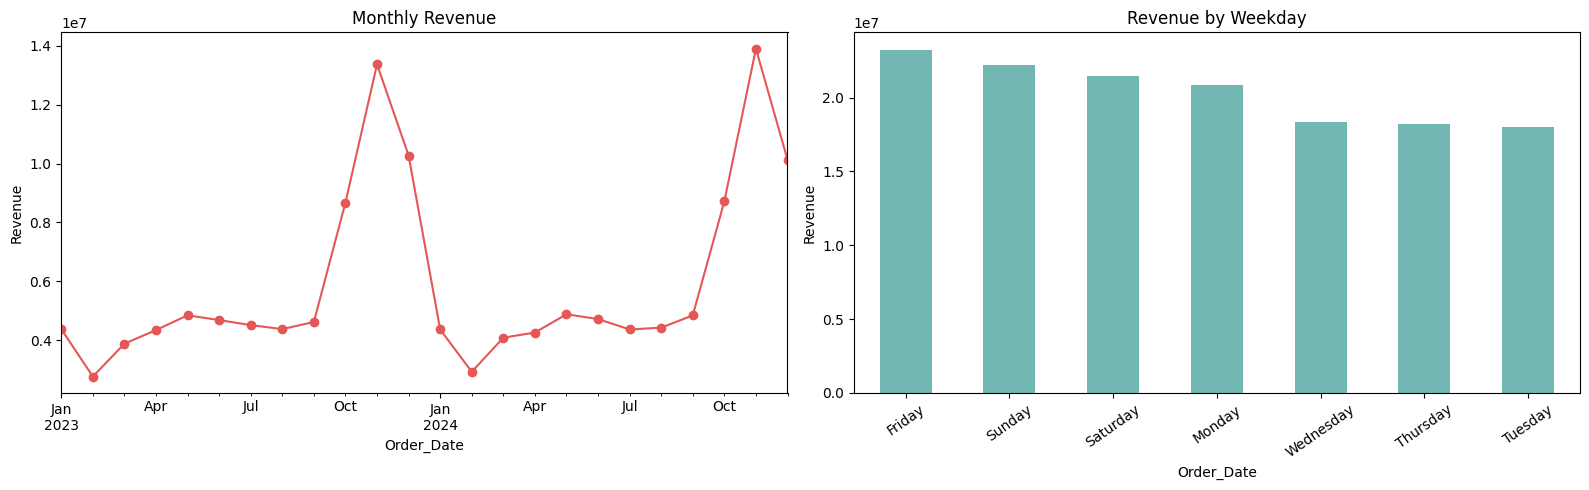

Order_Date
2023    70755372.66
2024    71652372.27
Name: Revenue, dtype: float64

Order_Date
2023Q1    11034564.44
2023Q2    13884013.74
2023Q3    13518012.68
2023Q4    32318781.80
2024Q1    11386883.10
2024Q2    13868467.20
2024Q3    13643435.40
2024Q4    32753586.57
Freq: Q-DEC, Name: Revenue, dtype: float64

Order_Date
Friday       23257334.62
Sunday       22234744.27
Saturday     21446039.30
Monday       20868890.69
Wednesday    18367437.36
Thursday     18197562.48
Tuesday      18035736.21
Name: Revenue, dtype: float64

In [39]:
monthly_revenue, quarterly_revenue, weekday_revenue = sales_era.plot_time_eda(df, PLOT_DIR)
yearly_revenue = df.groupby(df[DATE_COLUMN].dt.year)[TARGET].sum()

display(yearly_revenue.round(2))
display(quarterly_revenue.round(2))
display(weekday_revenue.round(2))

### Bước 4.1. EDA nâng cao - Target, QQ Plot và Rolling Mean

Phần này bổ sung các ý tưởng EDA hữu ích từ notebook `Predicting_product_sale_1`, nhưng áp dụng lại cho dataset hiện tại:

- QQ plot để xem `Revenue` có gần phân phối chuẩn hay không.
- Biến đổi log cho `Revenue` để xem độ lệch có giảm không.
- Heatmap tương quan giữa các đặc trưng số.
- Boxplot `Revenue` theo danh mục sản phẩm và khu vực.
- Chuỗi thời gian doanh thu theo ngày và rolling mean 7 ngày / 30 ngày.
- Moving average giúp quan sát xu hướng tốt hơn so với chỉ nhìn histogram riêng lẻ.

Mục tiêu: EDA phải có insight rõ ràng, không chỉ dừng ở việc vẽ biểu đồ.

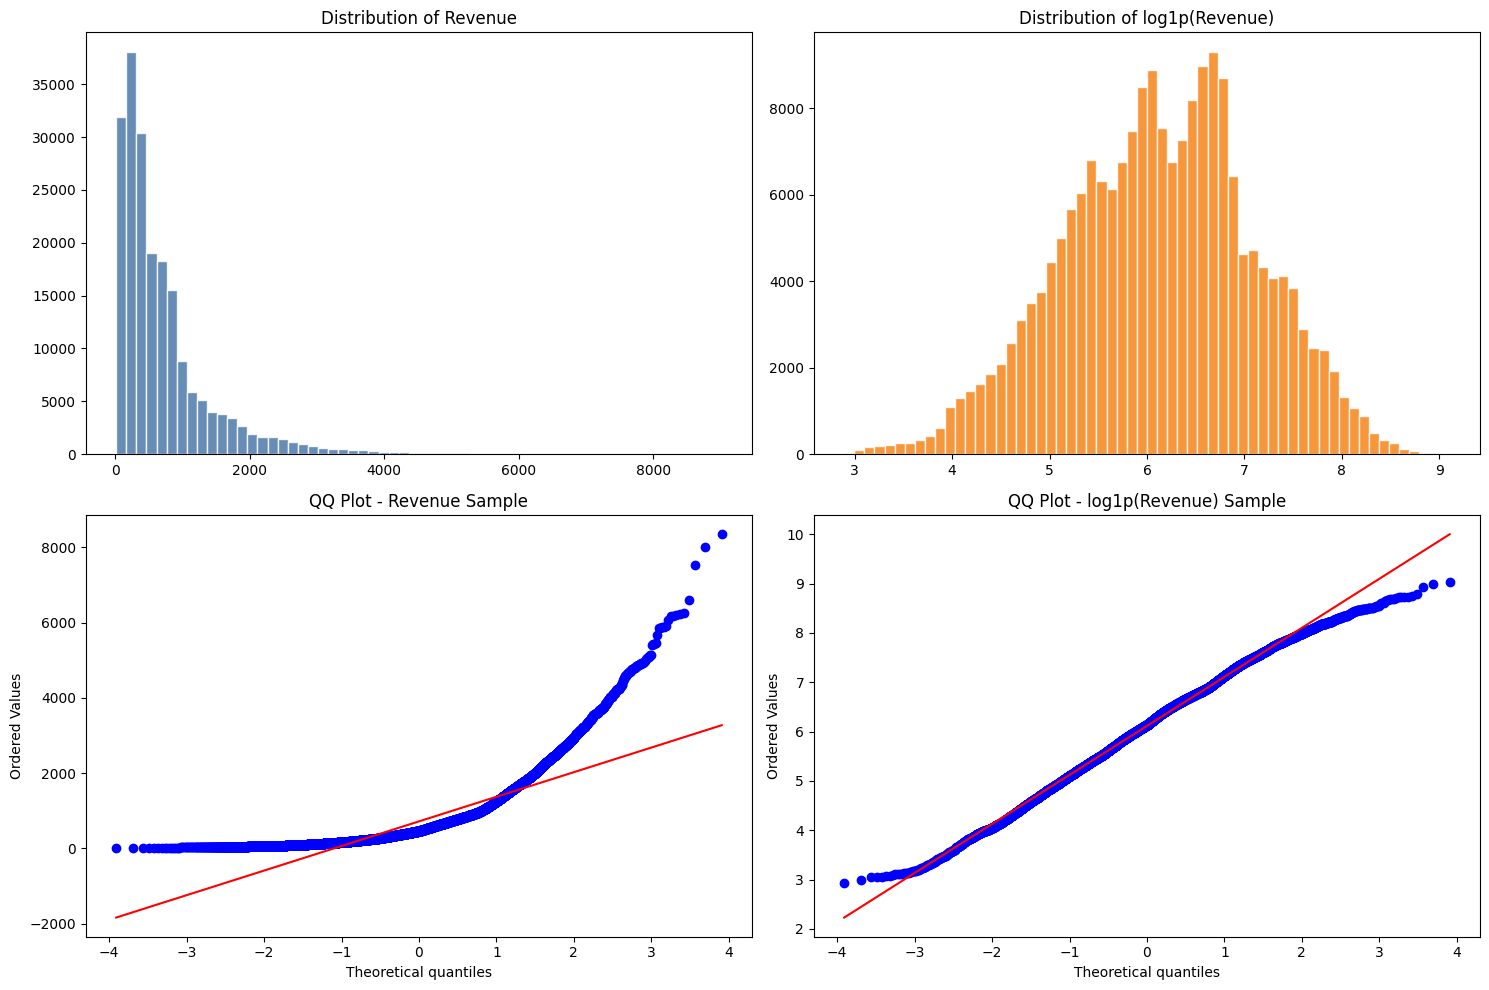

Revenue skewness: 2.5357
log1p(Revenue) skewness: -0.1462


In [40]:
sales_era.plot_advanced_target_distribution(df, PLOT_DIR)
print(f"Revenue skewness: {df[TARGET].skew():.4f}")
print(f"log1p(Revenue) skewness: {np.log1p(df[TARGET]).skew():.4f}")

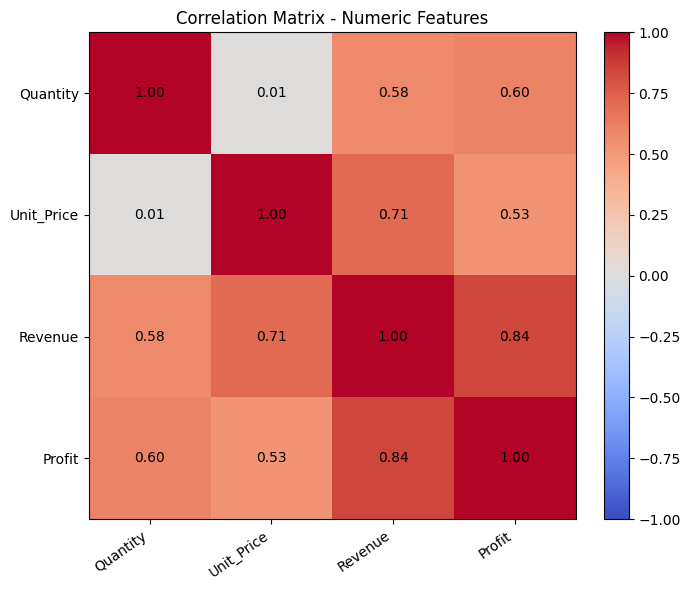

,Quantity,Unit_Price,Revenue,Profit
Quantity,1.0000,0.0073,0.5772,0.6025
Unit_Price,0.0073,1.0000,0.7062,0.5287
Revenue,0.5772,0.7062,1.0000,0.8413
Profit,0.6025,0.5287,0.8413,1.0000


In [41]:
display(sales_era.plot_numeric_correlation_heatmap(df, PLOT_DIR))

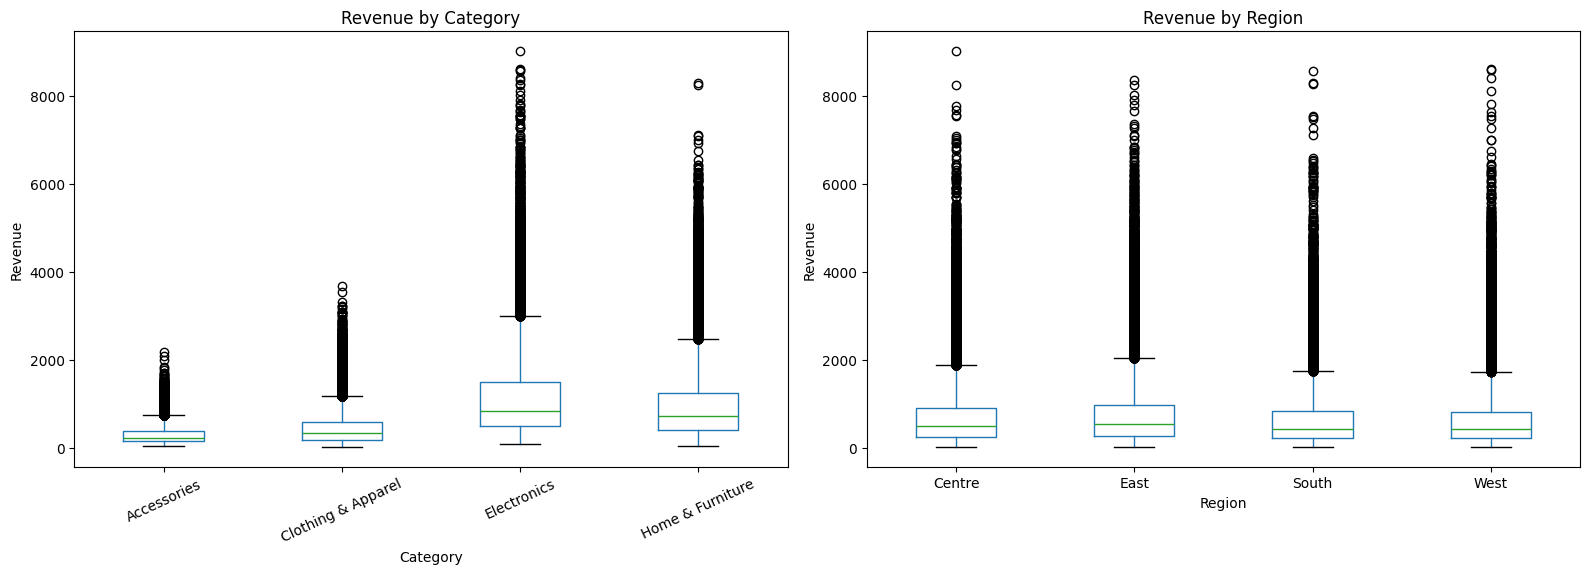

In [42]:
sales_era.plot_segment_boxplots(df, PLOT_DIR)

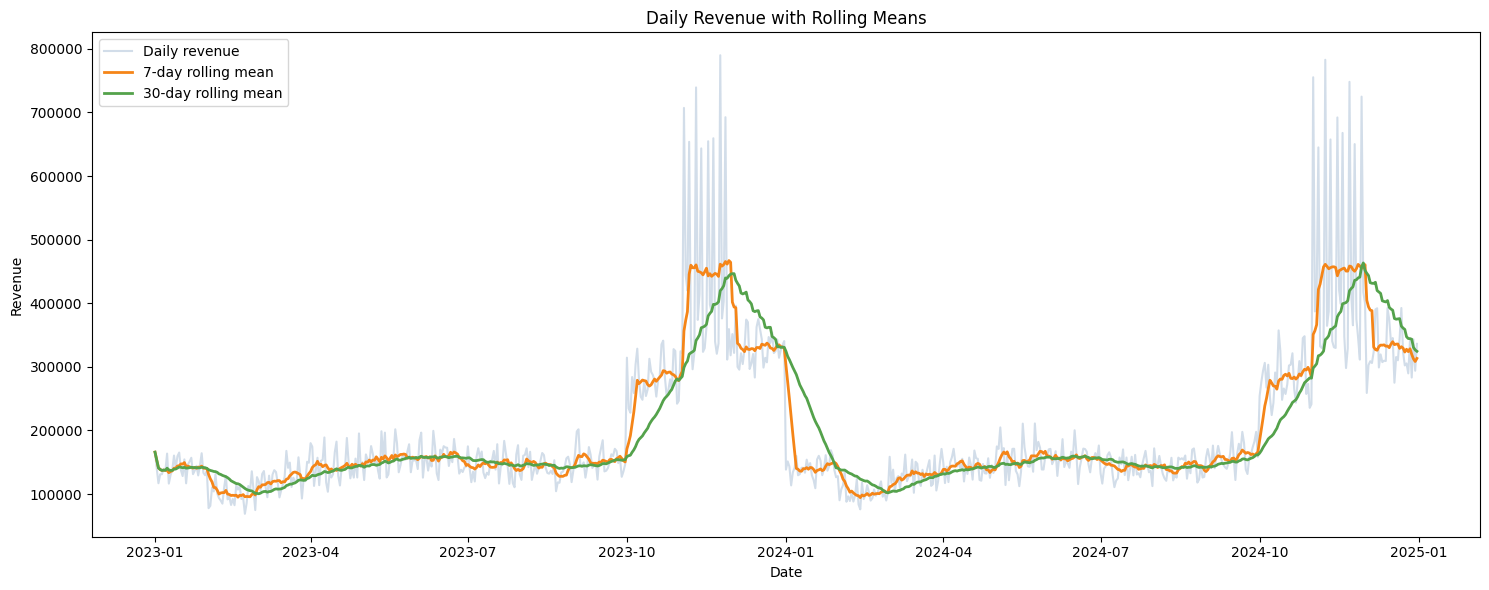

Insight:
- Rolling mean lam muot nhieu ngay doanh thu bien dong manh.
- Neu bai toan chuyen sang forecasting theo ngay/thang, cac lag va rolling features se rat huu ich.


In [43]:
sales_era.plot_daily_revenue_rolling_mean(df, PLOT_DIR)

print("Insight:")
print("- Rolling mean lam muot nhieu ngay doanh thu bien dong manh.")
print("- Neu bai toan chuyen sang forecasting theo ngay/thang, cac lag va rolling features se rat huu ich.")

### Bước 4.2. Bộ biểu đồ EDA bổ sung

Phần này bổ sung đầy đủ hơn các dạng biểu đồ trong notebook tham khảo, nhưng sử dụng đúng dataset hiện tại:

- Histogram kết hợp đường mật độ kiểu KDE.
- Count plot dạng bar chart.
- Bar chart tổng doanh thu.
- Boxplot theo phân khúc.
- Line chart theo thời gian.
- Dashboard EDA nhiều biểu đồ.
- So sánh phân phối trước và sau khi scaling.
- Scatter grid giữa đặc trưng và biến mục tiêu.

Các biểu đồ này giúp phần EDA gắn với dữ liệu và nghiệp vụ hơn: sản phẩm, giá, doanh thu, khu vực và xu hướng thời gian.

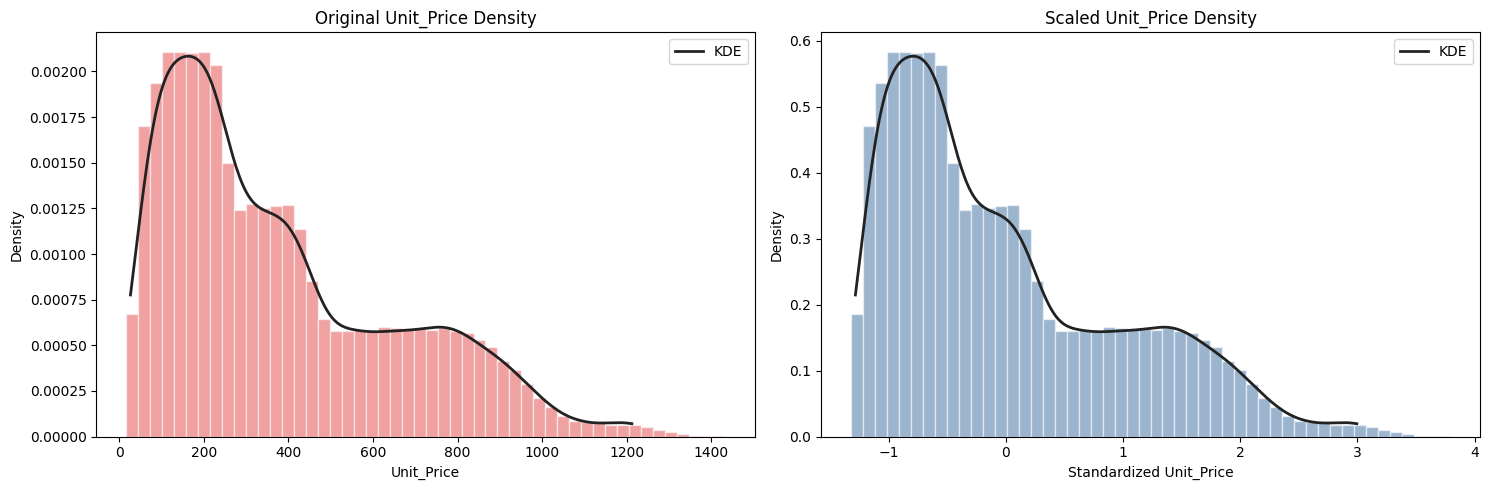

Scaling insight:
- Linear models such as Ridge benefit from scaling numeric features.
- Tree models are less sensitive to feature scale, but the shared preprocessing keeps the pipeline consistent.


In [45]:
sales_era.plot_density_original_vs_scaled(df, PLOT_DIR)

print("Scaling insight:")
print("- Linear models such as Ridge benefit from scaling numeric features.")
print("- Tree models are less sensitive to feature scale, but the shared preprocessing keeps the pipeline consistent.")

## Bước 5. Tạo đặc trưng

Các đặc trưng được tạo theo yêu cầu bài lab:
- Đặc trưng thời gian: `year`, `month`, `quarter`, `day_of_week`, `is_weekend`.
- Đặc trưng đại diện cho độ phổ biến/lịch sử sản phẩm: `product_order_count`, `product_avg_revenue`, `category_avg_revenue`.
- Đặc trưng lịch sử theo địa lý: `state_avg_revenue`, `region_avg_revenue`.

Điểm quan trọng: các đặc trưng aggregate phải được tính từ tập train, sau đó mới map sang tập test để giảm rủi ro rò rỉ thông tin từ tương lai.

In [47]:
train_df, test_df, aggregate_mappings, aggregate_defaults = sales_process.prepare_model_data(df)

print("Train rows:", len(train_df), train_df[DATE_COLUMN].min(), train_df[DATE_COLUMN].max())
print("Test rows:", len(test_df), test_df[DATE_COLUMN].min(), test_df[DATE_COLUMN].max())
display(train_df.head())


Train rows: 154048 2023-01-01 00:00:00 2024-09-30 00:00:00
Test rows: 45952 2024-10-01 00:00:00 2024-12-31 00:00:00


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit,year,month,quarter,day_of_week,is_weekend,product_order_count,product_avg_revenue,category_avg_revenue,state_avg_revenue,region_avg_revenue
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,2023,8,3,2,0,3693,339.336198,282.361532,659.645464,659.073889
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,2024,1,1,0,0,5470,484.755698,435.789813,735.254147,727.721272
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,2023,9,3,3,0,3803,288.971988,282.361532,779.262836,789.849534
7,8,2023-05-05,John Davis,Tulsa,Oklahoma,South,United States,Clothing & Apparel,Men's Wear,Levi's Jeans,1,329.29,329.29,65.91,2023,5,2,4,0,3706,460.984191,435.789813,682.651037,659.073889
8,9,2023-10-25,Edward Hicks,Salt Lake City,Utah,West,United States,Clothing & Apparel,Footwear,Timberland Boots,2,115.35,230.70,87.44,2023,10,4,2,0,2115,383.853083,435.789813,665.637206,653.219661


## Bước 6. Chọn tập đặc trưng và tiền xử lý

Các cột bị loại khỏi mô hình chính:
- `Order_ID`: chỉ là mã định danh dòng/đơn hàng.
- `Customer_Name`: có cardinality rất cao, dễ gây nhiễu và có rủi ro riêng tư.
- `Country`: chỉ có một giá trị nên không giúp mô hình học thêm thông tin.
- `Profit`: là kết quả sau bán hàng, có nguy cơ rò rỉ thông tin.
- `Revenue`: là biến mục tiêu.

In [48]:
DROP_FROM_FEATURES = sales_process.DROP_FROM_FEATURES
BASE_CATEGORICAL_FEATURES = sales_process.BASE_CATEGORICAL_FEATURES
TIME_FEATURES = sales_process.TIME_FEATURES
AGG_FEATURES = sales_process.AGG_FEATURES

def get_feature_sets(include_quantity: bool) -> tuple[list[str], list[str]]:
    numeric_features, categorical_features, _ = sales_process.get_feature_sets(include_quantity)
    return numeric_features, categorical_features

def make_one_hot_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ], remainder="drop")

def make_ordinal_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ], remainder="drop")

def make_models(include_quantity: bool) -> dict[str, Pipeline]:
    numeric_features, categorical_features = get_feature_sets(include_quantity)
    one_hot = make_one_hot_preprocessor(numeric_features, categorical_features)
    ordinal = make_ordinal_preprocessor(numeric_features, categorical_features)
    return {
        "Baseline_Mean": Pipeline([("preprocess", one_hot), ("model", DummyRegressor(strategy="mean"))]),
        "Ridge": Pipeline([("preprocess", one_hot), ("model", Ridge(alpha=1.0))]),
        "DecisionTree": Pipeline([("preprocess", one_hot), ("model", DecisionTreeRegressor(max_depth=16, min_samples_leaf=40, random_state=RANDOM_STATE))]),
        "RandomForest": Pipeline([("preprocess", one_hot), ("model", RandomForestRegressor(n_estimators=20, max_depth=12, min_samples_leaf=80, random_state=RANDOM_STATE, n_jobs=1))]),
        "HistGradientBoosting": Pipeline([("preprocess", ordinal), ("model", HistGradientBoostingRegressor(max_iter=100, learning_rate=0.08, l2_regularization=0.05, random_state=RANDOM_STATE))]),
    }

### Bước 6.1. Ghi chú thuật toán - Linear Regression và SVR

Phần này bổ sung lý thuyết từ notebook tham khảo, nhưng giữ trong notebook chính để phục vụ báo cáo.

### Linear Regression

Linear Regression giả định biến mục tiêu có quan hệ tuyến tính với các đặc trưng:

$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + ... + w_px_p
$$

Trong bài này:

- $y$ là `Revenue`.
- $x$ có thể là `Unit_Price`, các đặc trưng thời gian, sản phẩm/danh mục/địa lý sau khi encoding.
- Mô hình học các trọng số $w$ sao cho sai số dự đoán nhỏ nhất.

Hàm mất mát phổ biến là Mean Squared Error:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Ridge Regression là biến thể của Linear Regression có thêm regularization:

$$
Loss = MSE + \alpha\sum_{j=1}^{p}w_j^2
$$

Regularization giúp giảm overfitting khi có nhiều đặc trưng sau one-hot encoding.

### SVR - Support Vector Regression

SVR là phiên bản hồi quy của Support Vector Machine. Thay vì chỉ tối ưu sai số trung bình, SVR tạo một vùng dung sai epsilon quanh đường dự đoán:

$$
|y_i - \hat{y}_i| \leq \epsilon
$$

Nếu điểm dữ liệu nằm trong vùng epsilon, mô hình xem sai số đó là chấp nhận được. Nếu điểm nằm ngoài vùng epsilon, sai số mới bị phạt.

Hàm mất mát epsilon-insensitive:

$$
L_\epsilon(y, \hat{y}) = \max(0, |y - \hat{y}| - \epsilon)
$$

SVR phù hợp để giải thích học thuật và xử lý một số bài toán hồi quy có kích thước không quá lớn. Tuy nhiên, với dataset 200.000 dòng và nhiều đặc trưng categorical, SVR thường chậm hơn tree boosting hoặc linear model pipeline. Vì vậy notebook chính không huấn luyện SVR trên toàn bộ dữ liệu, nhưng vẫn giải thích thuật toán trong phần lý thuyết.

### Bước 6.2. Kiểm tra 3 mô hình tự cài đặt với sklearn

Phần này dùng 3 class trong `model_from_scratch.py`:

- `LinearRegressionScratch`
- `RidgeRegressionScratch`
- `LinearSVRRegressorScratch`

Mỗi mô hình tự cài đặt được double-check với mô hình sklearn tương ứng. Bảng kết quả sẽ in metric của Scratch, Sklearn và độ lệch `Scratch - Sklearn`.

Lưu ý: phần check này dùng các đặc trưng số đã engineered để giữ phần matrix math rõ ràng và tránh one-hot sparse matrix quá lớn.

In [49]:
scratch_numeric_features, _, _ = sales_process.get_feature_sets(include_quantity=False)

# Dùng numeric engineered features để kiểm tra các model from scratch.
x_train_scratch = train_df[scratch_numeric_features].head(5000)
y_train_scratch = train_df[TARGET].head(5000)
x_test_scratch = test_df[scratch_numeric_features].head(1000)
y_test_scratch = test_df[TARGET].head(1000)

comparison_rows = []

def append_metric_rows(algorithm_name: str, scratch_metrics: dict, sklearn_metrics: dict):
    diff_metrics = {key: scratch_metrics[key] - sklearn_metrics[key] for key in scratch_metrics}
    comparison_rows.extend([
        {"algorithm": algorithm_name, "source": "Scratch", **scratch_metrics},
        {"algorithm": algorithm_name, "source": "Sklearn", **sklearn_metrics},
        {"algorithm": algorithm_name, "source": "Scratch - Sklearn", **diff_metrics},
    ])

# 1. Linear Regression from scratch vs sklearn LinearRegression.
linear_checker = default_sklearn_linear_checker(scale=False)
linear_result = linear_checker.compare(
    LinearRegressionScratch(),
    x_train_scratch,
    y_train_scratch,
    x_test_scratch,
    y_test_scratch,
)
append_metric_rows("Linear Regression", linear_result.scratch_metrics, linear_result.sklearn_metrics)

# 2. Ridge Regression from scratch vs sklearn Ridge.
ridge_checker = default_sklearn_ridge_checker(alpha=1.0, scale=False)
ridge_result = ridge_checker.compare(
    RidgeRegressionScratch(alpha=1.0),
    x_train_scratch,
    y_train_scratch,
    x_test_scratch,
    y_test_scratch,
)
append_metric_rows("Ridge Regression", ridge_result.scratch_metrics, ridge_result.sklearn_metrics)

# 3. Linear SVR from scratch vs sklearn LinearSVR.
# SVR can gradient-descent better when X and y are scaled, so metrics are converted back to original Revenue scale.
x_scaler_svr = StandardScaler()
y_scaler_svr = StandardScaler()
x_train_svr = x_scaler_svr.fit_transform(x_train_scratch)
x_test_svr = x_scaler_svr.transform(x_test_scratch)
y_train_svr = y_scaler_svr.fit_transform(y_train_scratch.to_numpy().reshape(-1, 1)).ravel()

svr_scratch = LinearSVRRegressorScratch(
    epsilon=0.1,
    learning_rate=0.03,
    epochs=500,
    l2=0.001,
    random_state=RANDOM_STATE,
)
svr_scratch.fit(x_train_svr, y_train_svr)
svr_scratch_pred_scaled = svr_scratch.predict(x_test_svr)
svr_scratch_pred = y_scaler_svr.inverse_transform(svr_scratch_pred_scaled.reshape(-1, 1)).ravel()

svr_sklearn = LinearSVR(epsilon=0.1, C=1.0, max_iter=10000, random_state=RANDOM_STATE)
svr_sklearn.fit(x_train_svr, y_train_svr)
svr_sklearn_pred_scaled = svr_sklearn.predict(x_test_svr)
svr_sklearn_pred = y_scaler_svr.inverse_transform(svr_sklearn_pred_scaled.reshape(-1, 1)).ravel()

svr_scratch_metrics = regression_metrics(y_test_scratch, svr_scratch_pred)
svr_sklearn_metrics = regression_metrics(y_test_scratch, svr_sklearn_pred)
append_metric_rows("Linear SVR", svr_scratch_metrics, svr_sklearn_metrics)

scratch_vs_sklearn_metrics = pd.DataFrame(comparison_rows)
display(scratch_vs_sklearn_metrics.round(6))

print("Nhận xét double-check:")
print("- Linear Regression và Ridge Regression from scratch gần như trùng sklearn vì đều dùng nghiệm closed-form.")
print("- Linear SVR from scratch dùng sub-gradient descent nên có thể lệch sklearn LinearSVR, nhưng vẫn dùng cùng ý tưởng epsilon-insensitive loss.")
print("- Bảng trên in metric theo 3 thuật toán trong model_from_scratch.py: Linear Regression, Ridge Regression và Linear SVR.")


,model,MAE,MSE,RMSE,R2
0,RidgeRegressionScratch,336.737279,292077.600155,540.442041,0.480657
1,Sklearn Ridge Checker,336.737278,292077.600602,540.442042,0.480657
2,Scratch - Sklearn,0.000001,-0.000447,-0.000000,0.000000


## Bước 7. Huấn luyện và đánh giá mô hình

### Bước 7.1. Công thức các chỉ số đánh giá

Các chỉ số dùng để đánh giá mô hình hồi quy:

### MAE - Mean Absolute Error

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

MAE cho biết trung bình mô hình dự đoán lệch bao nhiêu đơn vị doanh thu. Chỉ số này dễ giải thích với góc nhìn kinh doanh.

### MSE - Mean Squared Error

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

MSE phạt nặng các lỗi lớn, nhưng đơn vị là bình phương doanh thu nên khó diễn giải trực tiếp.

### RMSE - Root Mean Squared Error

$$
RMSE = \sqrt{MSE}
$$

RMSE quay về cùng đơn vị với target và phạt nặng các lỗi lớn. Chỉ số này phù hợp vì `Revenue` có outlier và bị lệch phải.

### R2 - Coefficient of Determination

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

R2 cho biết mô hình giải thích được bao nhiêu phần trăm biến động của target. R2 gần 1 là tốt, gần 0 là chỉ ngang baseline mean, và âm là tệ hơn baseline.

In [ ]:
def regression_metrics(y_true, y_pred) -> dict[str, float]:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MSE": float(mse),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)),
    }

def train_variant(train_data: pd.DataFrame, test_data: pd.DataFrame, variant: str, include_quantity: bool):
    numeric_features, categorical_features = get_feature_sets(include_quantity)
    feature_columns = numeric_features + categorical_features
    sales_process.assert_no_leakage(feature_columns, include_quantity=include_quantity)

    x_train = train_data[feature_columns]
    y_train = train_data[TARGET]
    x_test = test_data[feature_columns]
    y_test = test_data[TARGET]

    rows = []
    fitted = {}
    preds = {}
    for model_name, model in make_models(include_quantity).items():
        print(f"Training {variant} / {model_name}...")
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        rows.append({
            "variant": variant,
            "model": model_name,
            "include_quantity": include_quantity,
            "feature_count": len(feature_columns),
            **regression_metrics(y_test, y_pred),
        })
        fitted[model_name] = model
        preds[model_name] = y_pred
    best_row = min(rows, key=lambda x: x["RMSE"])
    return rows, fitted[best_row["model"]], preds[best_row["model"]], feature_columns

model_a_rows, model_a_best, model_a_pred, model_a_features = train_variant(train_df, test_df, "Model_A_With_Quantity", True)
model_b_rows, model_b_best, model_b_pred, model_b_features = train_variant(train_df, test_df, "Model_B_No_Quantity", False)

metrics_df = pd.DataFrame(model_a_rows + model_b_rows).sort_values(["variant", "RMSE"])
display(metrics_df[["variant", "model", "MAE", "MSE", "RMSE", "R2", "feature_count"]].round(4))

Training Model_A_With_Quantity / Baseline_Mean...
Training Model_A_With_Quantity / Ridge...
Training Model_A_With_Quantity / DecisionTree...
Training Model_A_With_Quantity / RandomForest...


### Bước 7.2. So sánh chi tiết Model A và Model B

Phần này so sánh trực tiếp từng thuật toán trong hai phiên bản feature set:

- **Model A**: có dùng `Quantity`, nên metric rất cao nhưng có rủi ro rò rỉ dữ liệu.
- **Model B**: không dùng `Quantity`, nên thực tế hơn khi dự đoán doanh thu trước khi biết số lượng bán ra.

Mục tiêu của bảng này là nhìn rõ từng thuật toán cụ thể hoạt động thế nào trong A và B.

In [ ]:
comparison_ab = metrics_df[[
    "variant", "model", "include_quantity", "feature_count", "MAE", "MSE", "RMSE", "R2"
]].copy()

comparison_ab["feature_set_note"] = comparison_ab["variant"].map({
    "Model_A_With_Quantity": "Có Quantity - dùng để minh họa leakage",
    "Model_B_No_Quantity": "Không Quantity - phù hợp thực tế hơn",
})

comparison_ab = comparison_ab.sort_values(["variant", "RMSE"]).reset_index(drop=True)
print("Bảng so sánh tất cả thuật toán trong Model A và Model B:")
display(comparison_ab.round(4))

best_by_variant = comparison_ab.loc[
    comparison_ab.groupby("variant")["RMSE"].idxmin()
].sort_values("variant").reset_index(drop=True)

print("Mô hình tốt nhất trong từng phiên bản:")
display(best_by_variant.round(4))

model_a_best = best_by_variant[best_by_variant["variant"] == "Model_A_With_Quantity"].iloc[0]
model_b_best_row = best_by_variant[best_by_variant["variant"] == "Model_B_No_Quantity"].iloc[0]

print("Nhận xét:")
print(f"- Model A tốt nhất là {model_a_best['model']} với RMSE = {model_a_best['RMSE']:.2f}, nhưng dùng Quantity nên có leakage.")
print(f"- Model B tốt nhất là {model_b_best_row['model']} với RMSE = {model_b_best_row['RMSE']:.2f}, được ưu tiên vì không dùng Quantity.")
print("- Vì Revenue = Quantity * Unit_Price, Model A gần như biết trước một phần đáp án.")
print("- Do đó, Model B mới là lựa chọn chính cho báo cáo và demo dự đoán.")

Bảng so sánh tất cả thuật toán trong Model A và Model B:


,variant,model,include_quantity,feature_count,MAE,MSE,RMSE,R2,feature_set_note
0,Model_A_With_Quantity,HistGradientBoosting,True,18,5.1224,190.1856,13.7908,0.9997,Có Quantity - dùng để minh họa leakage
1,Model_A_With_Quantity,DecisionTree,True,18,3.3736,985.2579,31.3888,0.9982,Có Quantity - dùng để minh họa leakage
2,Model_A_With_Quantity,RandomForest,True,18,5.0155,1996.1189,44.6779,0.9964,Có Quantity - dùng để minh họa leakage
3,Model_A_With_Quantity,Ridge,True,18,199.3828,95778.0390,309.4803,0.8267,Có Quantity - dùng để minh họa leakage
4,Model_A_With_Quantity,Baseline_Mean,True,18,509.8041,552643.4202,743.3999,-0.0000,Có Quantity - dùng để minh họa leakage
5,Model_B_No_Quantity,Ridge,False,17,331.2022,272432.2811,521.9505,0.5070,Không Quantity - phù hợp thực tế hơn
6,Model_B_No_Quantity,HistGradientBoosting,False,17,330.4474,272520.5316,522.0350,0.5069,Không Quantity - phù hợp thực tế hơn
7,Model_B_No_Quantity,RandomForest,False,17,331.0552,272940.5794,522.4372,0.5061,Không Quantity - phù hợp thực tế hơn
8,Model_B_No_Quantity,DecisionTree,False,17,340.2276,287986.6855,536.6439,0.4789,Không Quantity - phù hợp thực tế hơn
9,Model_B_No_Quantity,Baseline_Mean,False,17,509.8041,552643.4202,743.3999,-0.0000,Không Quantity - phù hợp thực tế hơn


Mô hình tốt nhất trong từng phiên bản:


,variant,model,include_quantity,feature_count,MAE,MSE,RMSE,R2,feature_set_note
0,Model_A_With_Quantity,HistGradientBoosting,True,18,5.1224,190.1856,13.7908,0.9997,Có Quantity - dùng để minh họa leakage
1,Model_B_No_Quantity,Ridge,False,17,331.2022,272432.2811,521.9505,0.5070,Không Quantity - phù hợp thực tế hơn


Nhận xét:
- Model A tốt nhất là HistGradientBoosting với RMSE = 13.79, nhưng dùng Quantity nên có leakage.
- Model B tốt nhất là Ridge với RMSE = 521.95, được ưu tiên vì không dùng Quantity.
- Vì Revenue = Quantity * Unit_Price, Model A gần như biết trước một phần đáp án.
- Do đó, Model B mới là lựa chọn chính cho báo cáo và demo dự đoán.


## Bước 8. Diễn giải và lựa chọn mô hình

Model A có metric rất cao vì dùng `Quantity`, trong khi `Revenue = Quantity * Unit_Price`. Do đó Model A được xem là ví dụ minh họa rò rỉ dữ liệu.

Model B không dùng `Quantity`, nên phù hợp hơn nếu công ty muốn dự đoán doanh thu trước khi biết số lượng bán ra.

In [ ]:
best_business_row = metrics_df[metrics_df["variant"] == "Model_B_No_Quantity"].sort_values("RMSE").iloc[0].to_dict()
print("Selected final model:")
print(best_business_row)

print("\nModel A best, for leakage comparison only:")
display(metrics_df[metrics_df["variant"] == "Model_A_With_Quantity"].head(1).round(4))

print("\nModel B best, selected for deployment:")
display(metrics_df[metrics_df["variant"] == "Model_B_No_Quantity"].head(1).round(4))

Selected final model:
{'variant': 'Model_B_No_Quantity', 'model': 'Ridge', 'include_quantity': False, 'feature_count': 17, 'MAE': 331.20224255191886, 'MSE': 272432.281134545, 'RMSE': 521.9504585059246, 'R2': 0.5070370412224015}

Model A best, for leakage comparison only:


,variant,model,include_quantity,feature_count,MAE,MSE,RMSE,R2
4,Model_A_With_Quantity,HistGradientBoosting,True,18,5.1224,190.1856,13.7908,0.9997



Model B best, selected for deployment:


,variant,model,include_quantity,feature_count,MAE,MSE,RMSE,R2
6,Model_B_No_Quantity,Ridge,False,17,331.2022,272432.2811,521.9505,0.507


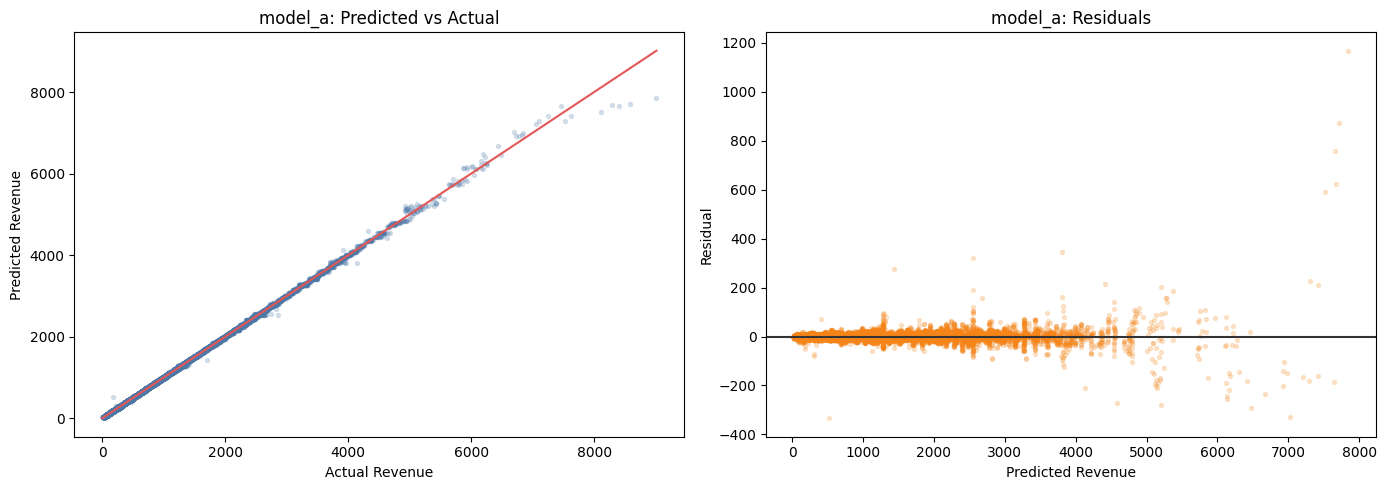

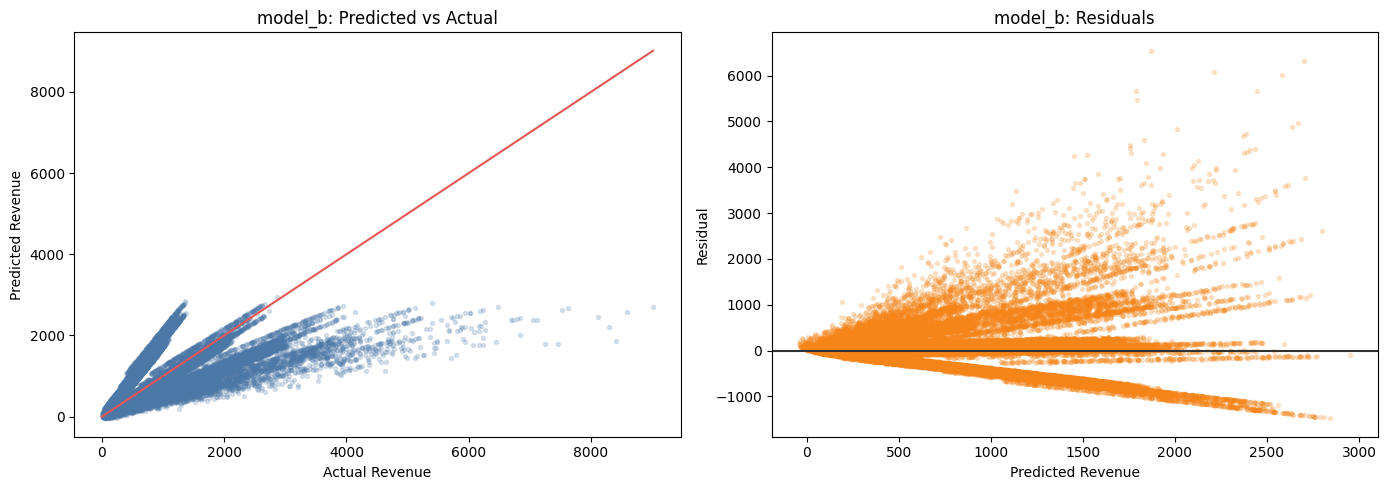

In [ ]:
sales_era.plot_predictions(test_df[TARGET], model_a_pred, "model_a", PLOT_DIR)
sales_era.plot_predictions(test_df[TARGET], model_b_pred, "model_b", PLOT_DIR)

In [ ]:
residual_analysis = test_df[[DATE_COLUMN, "Category"]].copy()
residual_analysis["actual"] = test_df[TARGET].to_numpy()
residual_analysis["predicted"] = model_b_pred
residual_analysis["residual"] = residual_analysis["actual"] - residual_analysis["predicted"]

print("Mean residual by category:")
display(residual_analysis.groupby("Category")["residual"].agg(["mean", "median", "std", "count"]).round(2))

print("Mean residual by month:")
display(residual_analysis.groupby(residual_analysis[DATE_COLUMN].dt.to_period("M"))["residual"].agg(["mean", "median", "std", "count"]).round(2))

Mean residual by category:


,mean,median,std,count
Category,,,,
Accessories,-0.70,-33.14,174.01,7984
Clothing & Apparel,1.19,-22.53,294.51,14561
Electronics,8.02,-84.85,750.24,11697
Home & Furniture,-3.05,-58.45,615.10,11710


Mean residual by month:


,mean,median,std,count
Order_Date,,,,
2024-10,4.43,-39.37,518.84,12222
2024-11,-1.95,-45.57,527.80,19469
2024-12,3.76,-40.44,516.57,14261


### Bước 8.1. Biểu đồ chẩn đoán mô hình

Phần này bổ sung các dạng biểu đồ trong notebook tham khảo sau khi đã huấn luyện mô hình:

- Actual vs Predicted theo thứ tự thời gian của tập test.
- Epsilon-tube style diagnostic: minh họa vùng sai số chấp nhận được quanh đường y=x.
- Feature weight chart cho mô hình Ridge cuối cùng.

Lưu ý: notebook này không huấn luyện SVR trên toàn bộ dataset. Epsilon tube ở đây là biểu đồ chẩn đoán lấy cảm hứng từ SVR, dùng ngưỡng epsilon bằng MAE của mô hình cuối cùng.

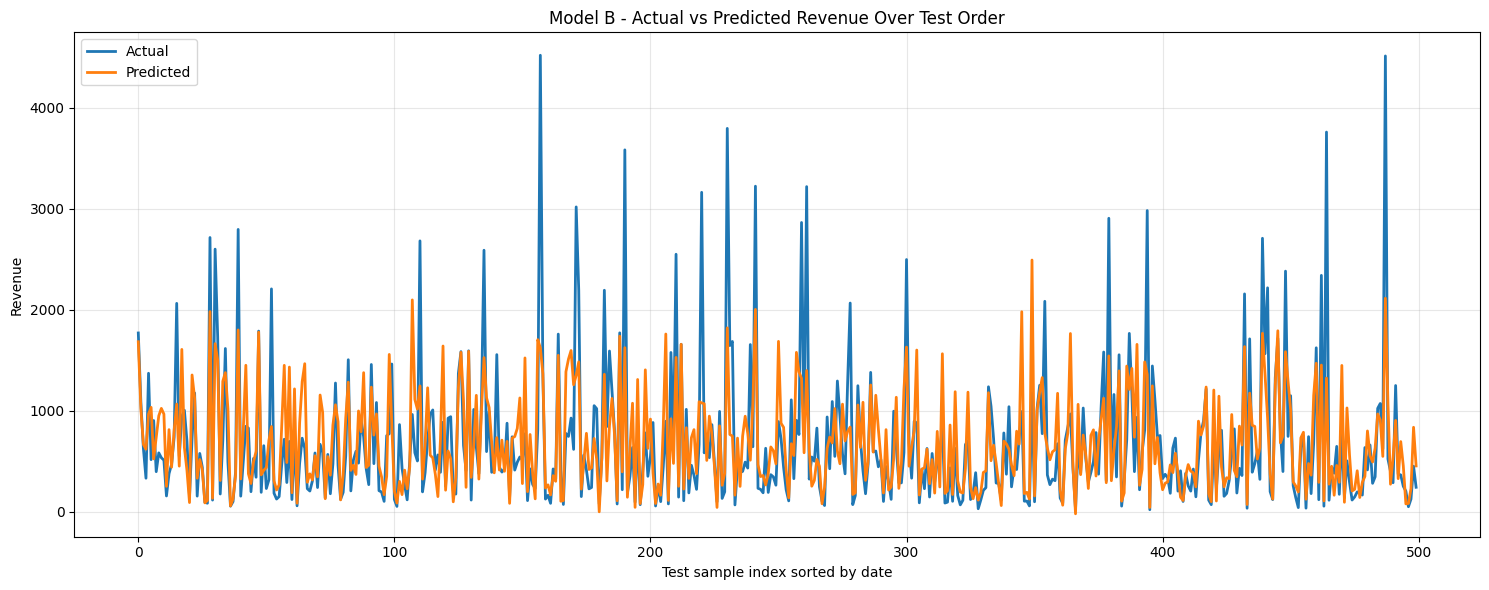

In [ ]:
sales_era.plot_actual_vs_predicted_line(test_df, model_b_pred, PLOT_DIR)

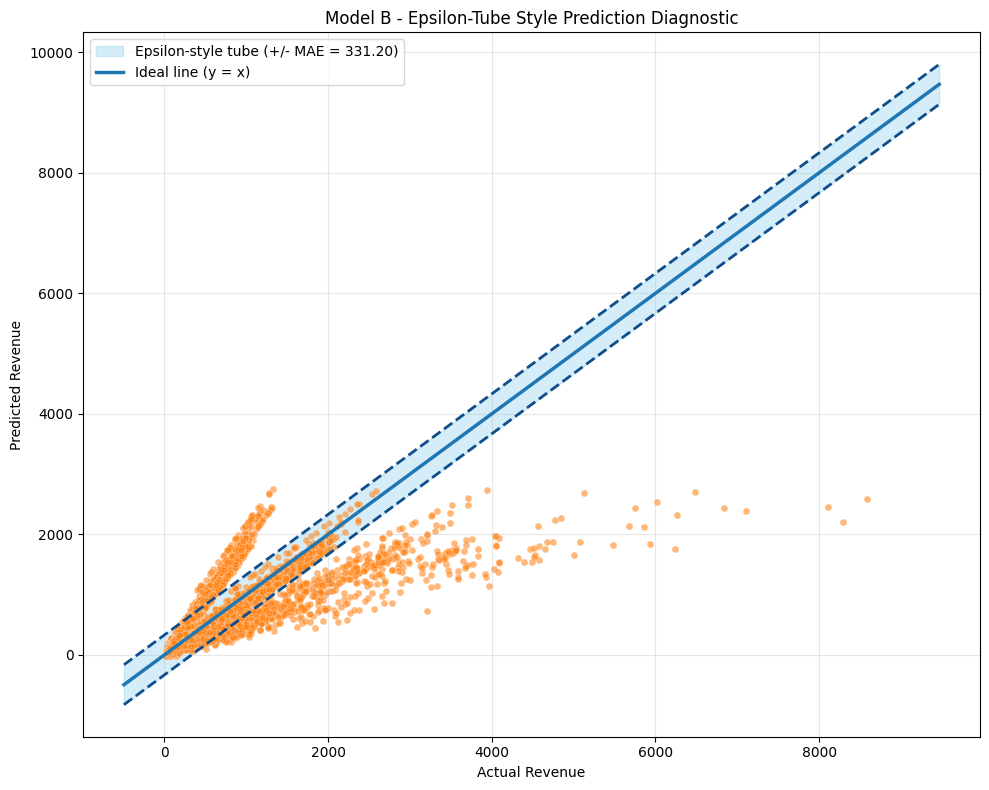

In [ ]:
sales_era.plot_epsilon_tube_diagnostic(test_df[TARGET], model_b_pred, PLOT_DIR)

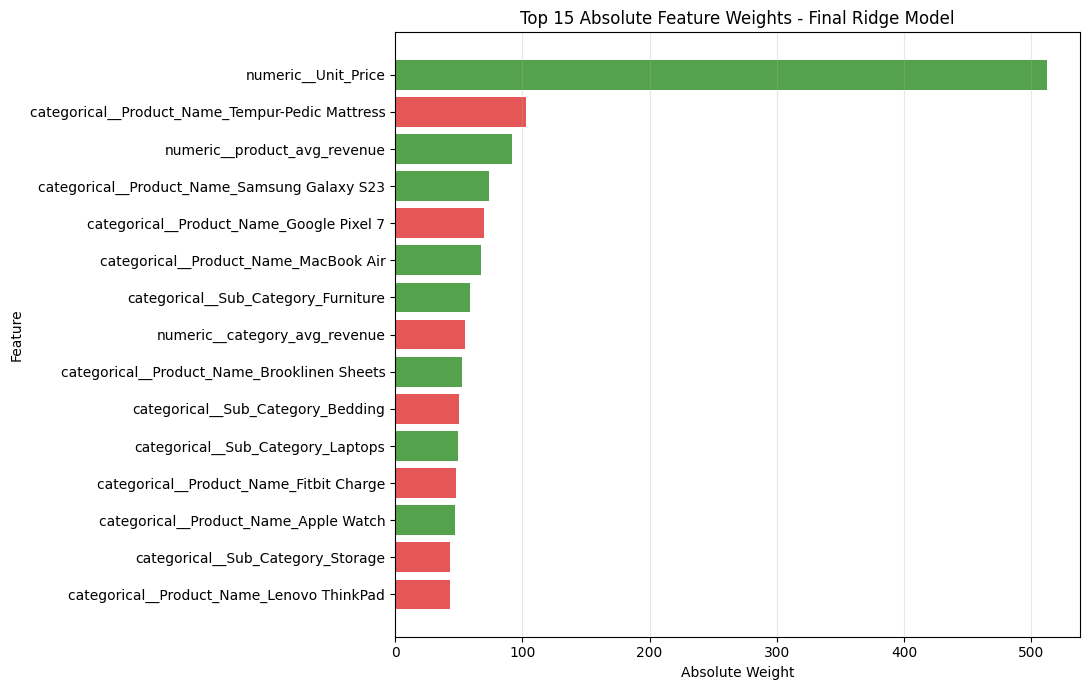

,feature,weight,abs_weight
0,numeric__Unit_Price,512.4860,512.4860
231,categorical__Product_Name_Tempur-Pedic Mattress,-103.0067,103.0067
7,numeric__product_avg_revenue,92.2252,92.2252
226,categorical__Product_Name_Samsung Galaxy S23,73.7183,73.7183
212,categorical__Product_Name_Google Pixel 7,-69.7025,69.7025
219,categorical__Product_Name_MacBook Air,67.5814,67.5814
177,categorical__Sub_Category_Furniture,58.7748,58.7748
8,numeric__category_avg_revenue,-55.1100,55.1100
200,categorical__Product_Name_Brooklinen Sheets,52.8661,52.8661
175,categorical__Sub_Category_Bedding,-50.1406,50.1406


In [ ]:
display(sales_era.plot_linear_feature_weights(model_b_best, PLOT_DIR))

## Bước 9. Lưu báo cáo và artifact

In [ ]:
eda_summary = {
    "data_checks": data_checks,
    "target_summary": {k: float(v) for k, v in target_summary.items()},
    "top_category_revenue": top_category.reset_index().to_dict("records"),
    "top_sub_category_revenue": top_sub_category.reset_index().to_dict("records"),
    "top_product_revenue": top_product.reset_index().to_dict("records"),
    "top_region_revenue": top_region.reset_index().to_dict("records"),
    "top_state_revenue": top_state.reset_index().to_dict("records"),
    "top_city_revenue": top_city.reset_index().to_dict("records"),
}

metrics_payload = {
    "selected_model": best_business_row,
    "metrics": metrics_df.to_dict("records"),
    "feature_columns": model_b_features,
    "test_start_date": str(TEST_START_DATE.date()),
    "excluded_columns": DROP_FROM_FEATURES,
    "note": "Final model excludes Quantity to avoid leakage. Model A is included only for comparison.",
}

(REPORT_DIR / "notebook_eda_summary.json").write_text(json.dumps(eda_summary, indent=2, default=str), encoding="utf-8")
(ARTIFACT_DIR / "notebook_metrics.json").write_text(json.dumps(metrics_payload, indent=2, default=str), encoding="utf-8")
(ARTIFACT_DIR / "notebook_feature_columns.json").write_text(json.dumps(model_b_features, indent=2), encoding="utf-8")

joblib.dump(model_b_best, ARTIFACT_DIR / "notebook_best_model.joblib")
joblib.dump(
    {
        "model": model_b_best,
        "selected_model": best_business_row,
        "feature_columns": model_b_features,
        "aggregate_mappings": aggregate_mappings,
        "aggregate_defaults": aggregate_defaults,
        "date_column": DATE_COLUMN,
        "date_format": DATE_FORMAT,
        "target": TARGET,
    },
    ARTIFACT_DIR / "notebook_model_bundle.joblib",
)

print("Saved notebook artifacts to:", ARTIFACT_DIR)
print("Saved notebook reports to:", REPORT_DIR)

Saved notebook artifacts to: /Users/quangmanh/Project/lab02/artifacts
Saved notebook reports to: /Users/quangmanh/Project/lab02/reports


## Bước 10. Demo dự đoán

Demo này tạo một input mới, sinh các engineered features, sau đó dự đoán `Revenue` bằng Model B cuối cùng.

In [ ]:
sample_order = {
    "Order_Date": "12-15-24",
    "City": "Boston",
    "State": "Massachusetts",
    "Region": "East",
    "Category": "Electronics",
    "Sub_Category": "Laptops",
    "Product_Name": "MacBook Air",
    "Unit_Price": 999.99,
}

sample_features = sales_process.prepare_single_input(
    sample_order,
    feature_columns=model_b_features,
    aggregate_mappings=aggregate_mappings,
    aggregate_defaults=aggregate_defaults,
)
sample_prediction = float(model_b_best.predict(sample_features)[0])
print("Predicted revenue:", round(sample_prediction, 2))
display(sample_features)


Predicted revenue: 2175.44


,Unit_Price,year,month,quarter,day_of_week,is_weekend,product_order_count,product_avg_revenue,category_avg_revenue,state_avg_revenue,region_avg_revenue,City,State,Region,Category,Sub_Category,Product_Name
0,999.99,2024,12,4,6,1,3035,1868.759858,1118.48317,792.325884,789.849534,Boston,Massachusetts,East,Electronics,Laptops,MacBook Air


## Bước 11. Kết luận cuối cùng

- Dataset phù hợp với bài toán dự đoán doanh thu sản phẩm: có thông tin sản phẩm, giá, số lượng, địa lý, doanh thu, lợi nhuận và ngày đặt hàng.
- Dữ liệu sạch: không có missing values, không có dòng trùng lặp, và cột ngày được parse thành công 100%.
- `Revenue` là biến mục tiêu hợp lý nhất.
- `Profit` bị loại vì là biến hậu nghiệm sau bán hàng.
- `Country` bị loại vì chỉ có một giá trị.
- `Customer_Name` bị loại khỏi mô hình chính vì cardinality cao và không phù hợp làm demographic feature.
- Model A có metric rất cao nhưng bị rò rỉ dữ liệu vì dùng `Quantity`.
- Model B không dùng `Quantity`, nên thực tế hơn và được chọn làm mô hình cuối cùng.
- Để cải thiện trong tương lai, nên bổ sung campaign, discount, ad spend, rating, review, inventory và lịch sử mua hàng thật của khách hàng.